In [1]:
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as F
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [2]:
CLASS_NAMES = {1: 'tumor'}
num_classes = 2  

In [3]:
############################################
# 1. Custom Dataset for Brain Tumor Segmentation
############################################

class BrainTumorDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transforms=None):
        """
        Args:
            images_dir (str): Directory with all the images.
            masks_dir (str): Directory with all the corresponding mask images.
            transforms (callable, optional): A function/transform that takes in an image and a target dict,
                and returns a transformed version.
        """
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transforms = transforms
        # Assume image files are .jpg or .png and masks share the same filename.
        self.image_files = sorted([f for f in os.listdir(images_dir)
                                   if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        # Load image.
        image_filename = self.image_files[idx]
        image_path = os.path.join(self.images_dir, image_filename)
        mask_path = os.path.join(self.masks_dir, image_filename)  # assumes same file names
        
        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale
        
        # Convert mask to numpy array and threshold it (assumes nonzero pixels mark the tumor).
        mask_np = np.array(mask)
        mask_np = (mask_np > 128).astype(np.uint8)  # binary mask: 0 or 1
        
        w, h = image.size
        
        # If there is a tumor in the mask, compute the bounding box.
        if mask_np.sum() > 0:
            pos = np.where(mask_np > 0)
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes = [[xmin, ymin, xmax, ymax]]
            labels = [1]  # tumor class
            # Ensure mask has shape (N, H, W)
            masks = np.expand_dims(mask_np, axis=0)
            area = (xmax - xmin) * (ymax - ymin)
            iscrowd = [0]
        else:
            # In case no tumor is present, return empty annotations.
            boxes = []
            labels = []
            masks = np.zeros((0, h, w), dtype=np.uint8)
            area = 0
            iscrowd = []
        
        # Convert lists to tensors.
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        masks = torch.as_tensor(masks, dtype=torch.uint8)
        if area > 0:
            area = torch.as_tensor([area], dtype=torch.float32)
        else:
            area = torch.zeros((0,), dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        
        target = {
            "boxes": boxes,         # (N, 4)
            "labels": labels,       # (N,)
            "masks": masks,         # (N, H, W)
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd
        }
        
        if self.transforms is not None:
            image, target = self.transforms(image, target)
        
        return image, target

In [4]:
############################################
# 2. Transforms: Compose, ToTensor, RandomHorizontalFlip
############################################

class Compose(object):
    """Composes several transforms together."""
    def __init__(self, transforms):
        self.transforms = transforms
    
    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

class ToTensor(object):
    """Convert a PIL image to a tensor."""
    def __call__(self, image, target):
        image = F.to_tensor(image)
        return image, target

class RandomHorizontalFlip(object):
    """Randomly flip the image (and adjust bounding boxes and masks) horizontally with a given probability."""
    def __init__(self, prob=0.5):
        self.prob = prob
    
    def __call__(self, image, target):
        if random.random() < self.prob:
            image = F.hflip(image)
            w, _ = image.size
            boxes = target["boxes"].clone()
            if boxes.numel() > 0:
                boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
            target["boxes"] = boxes

            if "masks" in target:
                masks = target["masks"]
                # If mask is a numpy array, convert it to tensor.
                if isinstance(masks, np.ndarray):
                    masks = torch.as_tensor(masks, dtype=torch.uint8)
                target["masks"] = masks.flip(-1)
        return image, target

def get_transform(train):
    transforms = []
    if train:
        transforms.append(RandomHorizontalFlip(0.5))
    transforms.append(ToTensor())
    return Compose(transforms)

def collate_fn(batch):
    return tuple(zip(*batch))

In [5]:
############################################
# 3. Visualization Helpers
############################################

def visualize_ground_truth_samples(dataset, num_samples=3):
    """Display a few images with ground-truth bounding boxes and class labels."""
    indices = random.sample(range(len(dataset)), num_samples)
    for idx in indices:
        image, target = dataset[idx]
        # Convert image to PIL format if necessary.
        image_pil = F.to_pil_image(image) if isinstance(image, torch.Tensor) else image

        plt.figure(figsize=(12, 8))
        plt.imshow(image_pil)
        ax = plt.gca()

        if target["masks"].numel() > 0:
            masks = target["masks"].numpy()  # shape: (N, H, W)
            boxes = target["boxes"].numpy() if target["boxes"].numel() > 0 else []
            labels = target["labels"].numpy() if target["labels"].numel() > 0 else []
            # Overlay each mask.
            for i in range(masks.shape[0]):
                mask = masks[i]
                # Assuming the mask is binary already; if not, you can threshold it.
                binary_mask = mask > 0
                plt.imshow(binary_mask, cmap='Greens', alpha=0.5)
                
                # Optionally, draw the corresponding bounding box.
                pos = np.where(binary_mask)
                if pos[0].size > 0:
                    xmin = np.min(pos[1])
                    xmax = np.max(pos[1])
                    ymin = np.min(pos[0])
                    ymax = np.max(pos[0])
                    rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                         fill=False, edgecolor="blue", linewidth=2)
                    ax.add_patch(rect)
                    display_label = CLASS_NAMES.get(labels[i], str(labels[i]))
                    ax.text(xmin, ymin - 10, f"GT: {display_label}", color="blue", fontsize=12,
                            weight="bold", backgroundcolor="white")
        
        plt.title(f"Ground Truth with Segmentation Mask - Sample {idx}")
        plt.axis('off')
        plt.show()

def visualize_predictions(model, data_loader, device, num_samples=3, score_threshold=0.5):
    """
    Run the model on a few test images and display predictions vs. ground truth.
    Boxes are annotated with class labels (and for predictions, confidence scores).
    """
    model.eval()
    count = 0
    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            outputs = model(images)
            for img, target, output in zip(images, targets, outputs):
                # Move image to CPU and convert to PIL image.
                img_cpu = img.cpu()
                img_pil = F.to_pil_image(img_cpu) if isinstance(img_cpu, torch.Tensor) else img_cpu
                
                plt.figure(figsize=(12, 8))
                plt.imshow(img_pil)
                ax = plt.gca()
                
                # Process predicted masks, scores, and labels.
                pred_masks = output["masks"].cpu()  # shape: (N, 1, H, W)
                pred_scores = output["scores"].cpu()
                pred_labels = output["labels"].cpu()
                
                # Filter predictions based on score threshold.
                keep = pred_scores >= score_threshold
                pred_masks = pred_masks[keep]
                pred_scores = pred_scores[keep]
                pred_labels = pred_labels[keep]
                
                # Loop through each predicted mask.
                for i, mask in enumerate(pred_masks):
                    # Remove the channel dimension.
                    mask = mask[0]
                    # Threshold the mask to obtain a binary mask.
                    binary_mask = mask > 0.5
                    # Overlay the mask on the image. You can adjust alpha and colormap as needed.
                    plt.imshow(binary_mask.numpy(), alpha=0.5, cmap='Reds')
                    
                    # Optionally, draw a bounding box around the predicted mask.
                    pos = np.where(binary_mask.numpy())
                    if pos[0].size > 0:
                        xmin = np.min(pos[1])
                        xmax = np.max(pos[1])
                        ymin = np.min(pos[0])
                        ymax = np.max(pos[0])
                        rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                             fill=False, edgecolor="blue", linewidth=2)
                        ax.add_patch(rect)
                        display_label = CLASS_NAMES.get(pred_labels[i].item(), str(pred_labels[i].item()))
                        ax.text(xmin, ymin - 10, f"Pred: {display_label} ({pred_scores[i]:.2f})", 
                                color="blue", fontsize=12, weight="bold", backgroundcolor="white")
                
                plt.title("Predicted Segmentation Masks")
                plt.axis('off')
                plt.show()
                
                count += 1
                if count >= num_samples:
                    return

In [6]:
############################################
# 4. Evaluation: Compute mAP Using torchmetrics
############################################

def evaluate_map(model, data_loader, device, score_threshold=0.5):
    """
    Evaluate the model on the given data_loader using Mean Average Precision (mAP).
    """
    model.eval()
    metric = MeanAveragePrecision()

    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            outputs = model(images)

            preds = []
            gts = []
            for target, output in zip(targets, outputs):
                # Ground truth.
                gt = {
                    "boxes": target["boxes"].cpu(),
                    "labels": target["labels"].cpu()
                }
                gts.append(gt)

                # Filter predictions.
                scores = output["scores"].cpu()
                keep = scores >= score_threshold
                pred = {
                    "boxes": output["boxes"].cpu()[keep],
                    "scores": scores[keep],
                    "labels": output["labels"].cpu()[keep]
                }
                preds.append(pred)
            metric.update(preds, gts)
    
    result = metric.compute()
    return result

Visualizing sample ground truth images...


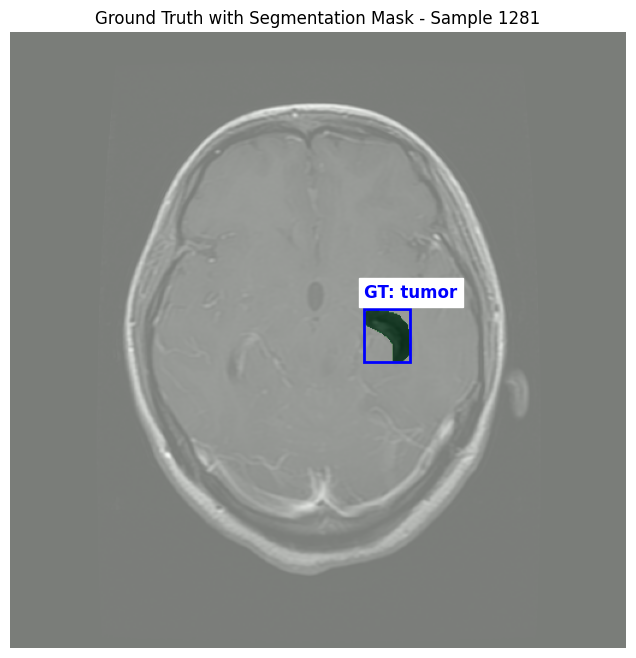

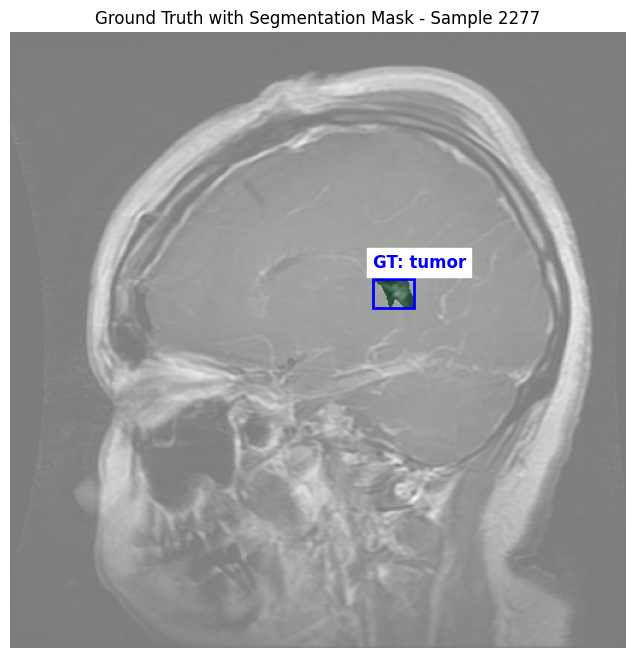

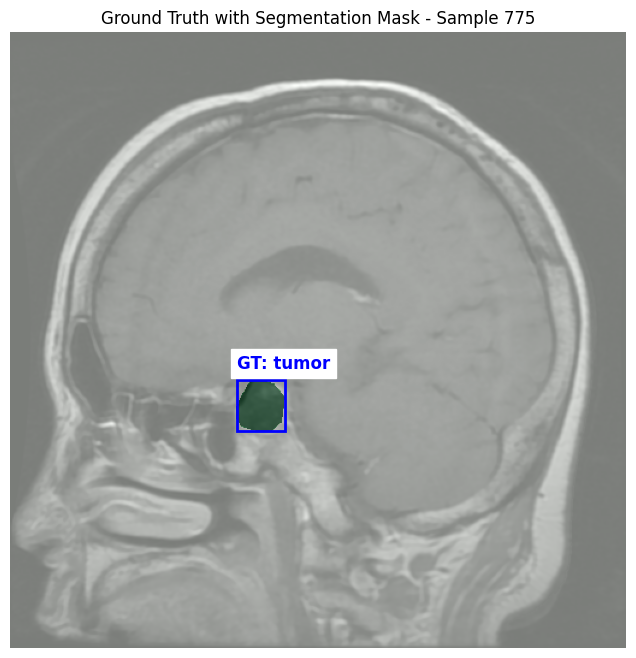

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_V2_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         

In [7]:
############################################
# 5. Prepare Dataset, DataLoaders, and Model
############################################

# Replace these paths with your dataset directories.
images_dir = r"/kaggle/input/brain-tumor-segmentation/images"
masks_dir = r"/kaggle/input/brain-tumor-segmentation/masks"

# Create dataset and (optionally) split into train/test.
full_dataset = BrainTumorDataset(images_dir, masks_dir, transforms=get_transform(train=True))
dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
test_size = dataset_size - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# For testing/visualization, use no augmentation.
test_dataset.dataset.transforms = get_transform(train=False)

# Visualize some ground truth samples.
print("Visualizing sample ground truth images...")
visualize_ground_truth_samples(train_dataset.dataset, num_samples=3)

# Create DataLoaders.
data_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
data_loader_test = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Load a pre-trained Mask R-CNN model.
model = maskrcnn_resnet50_fpn_v2(pretrained=True)

# Replace the box predictor with one for our number of classes.
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Replace the mask predictor.
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

model.to(device)

Start training...


Epoch 1/10: 100%|██████████| 307/307 [06:26<00:00,  1.26s/it]


Epoch [1/10] finished with average loss: 0.3999


Epoch 2/10: 100%|██████████| 307/307 [06:24<00:00,  1.25s/it]


Epoch [2/10] finished with average loss: 0.2694


...

Epoch [8/10] finished with average loss: 0.1239


Epoch 9/10: 100%|██████████| 307/307 [06:25<00:00,  1.25s/it]


Epoch [9/10] finished with average loss: 0.1157


Epoch 10/10: 100%|██████████| 307/307 [06:25<00:00,  1.26s/it]


Epoch [10/10] finished with average loss: 0.1077
Model checkpoint saved at model/rcnn_brain_tumor_epoch_10.pth
Training complete.


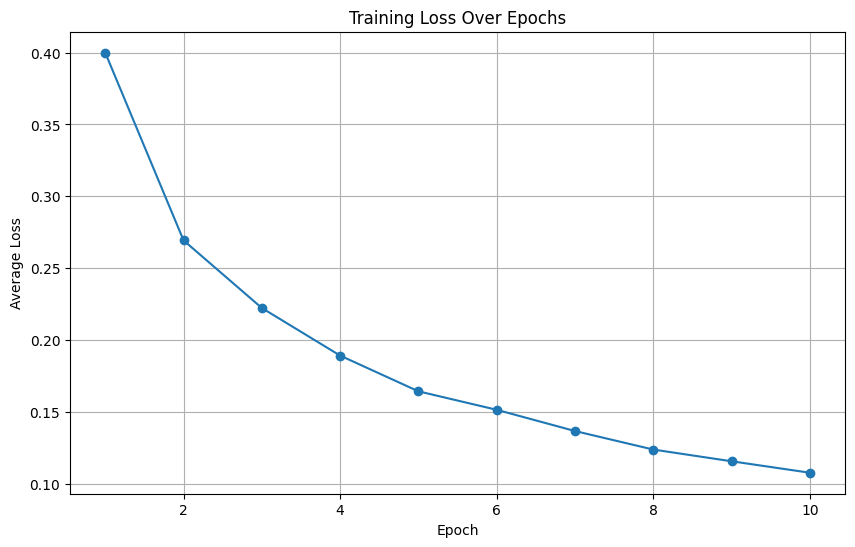

In [8]:
############################################
# 6. Training Loop
############################################
from tqdm import tqdm
# Set up optimizer.
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

num_epochs = 10
epoch_losses = []  # Store average loss per epoch.

print("Start training...")
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for images, targets in tqdm(data_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        epoch_loss += losses.item()
    avg_loss = epoch_loss / len(data_loader)
    epoch_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] finished with average loss: {avg_loss:.4f}")
    
    # Save checkpoint every 5 epochs.
    if (epoch + 1) % 5 == 0:
        checkpoint_path = f"model/rcnn_brain_tumor_epoch_{epoch+1}.pth"
        os.makedirs("model", exist_ok=True)
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Model checkpoint saved at {checkpoint_path}")

print("Training complete.")

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs+1), epoch_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()

Evaluating mAP on the test set...
mAP Results: {'map': tensor(0.5266), 'map_50': tensor(0.7997), 'map_75': tensor(0.5757), 'map_small': tensor(0.3239), 'map_medium': tensor(0.5494), 'map_large': tensor(0.5489), 'mar_1': tensor(0.5817), 'mar_10': tensor(0.5896), 'mar_100': tensor(0.5896), 'mar_small': tensor(0.3808), 'mar_medium': tensor(0.6146), 'mar_large': tensor(0.5911), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor(1, dtype=torch.int32)}
Visualizing sample predictions...


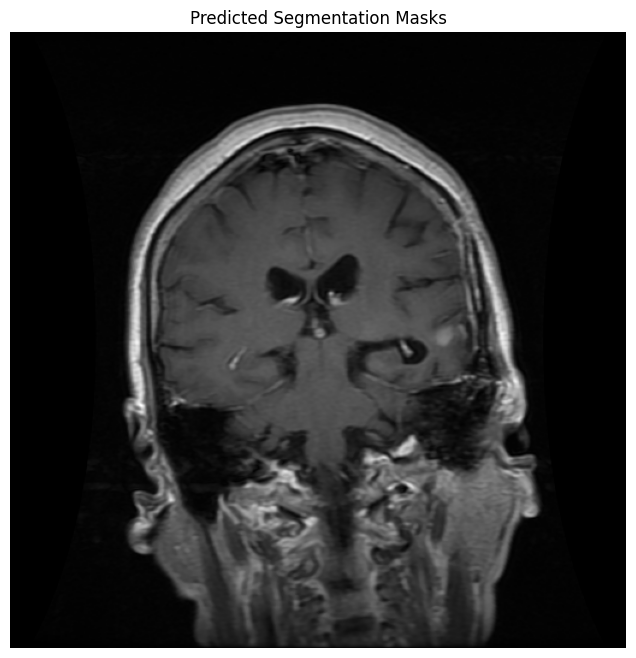

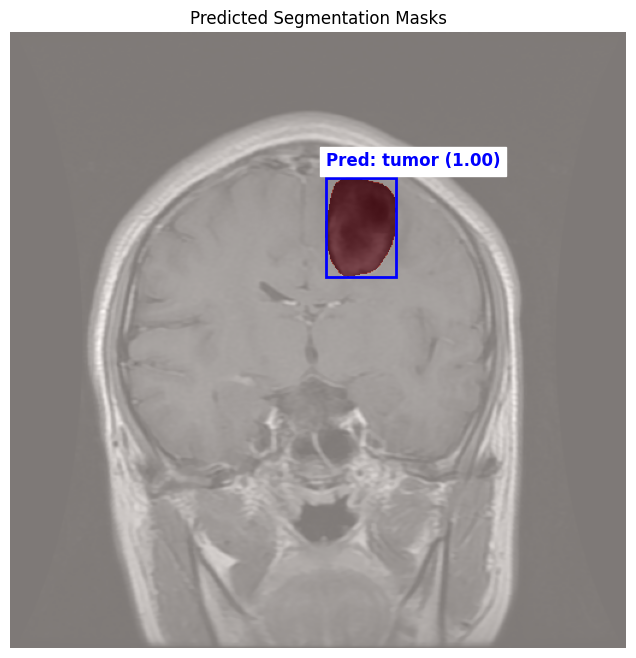

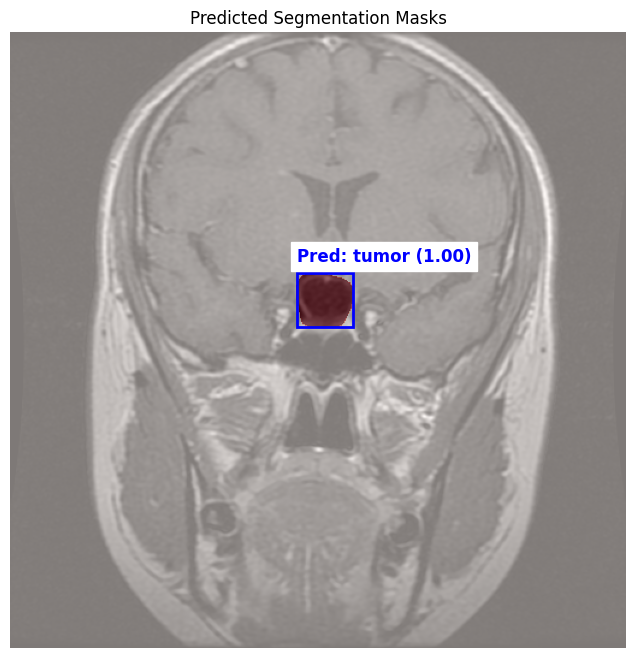

In [9]:
############################################
# 7. Evaluation and Visualization
############################################

print("Evaluating mAP on the test set...")
map_results = evaluate_map(model, data_loader_test, device, score_threshold=0.5)
print("mAP Results:", map_results)

print("Visualizing sample predictions...")
visualize_predictions(model, data_loader_test, device, num_samples=3, score_threshold=0.5)